# Load cleaned dataset

In [1]:
# Load cleaned dataset
import pandas as pd

df = pd.read_csv("churn_cleaned.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.isnull().sum().sum()

np.int64(0)

# Feature Engineering

### Encoding → Label Encoding

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Churn"] = le.fit_transform(df["Churn"])

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [5]:
print(le.classes_)

['No' 'Yes']


### Encoding → One-Hot Encoding

In [6]:
categorical_features = df.select_dtypes(include="object").columns
categorical_features = categorical_features.drop("customerID")

df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

df_encoded.head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,29.85,29.85,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
1,5575-GNVDE,0,34,56.95,1889.50,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,0,2,53.85,108.15,1,1,0,0,1,...,0,0,0,0,0,0,1,0,0,1
3,7795-CFOCW,0,45,42.30,1840.75,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,9237-HQITU,0,2,70.70,151.65,1,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0


In [7]:
# Remove customer ID
df_encoded = df_encoded.drop("customerID", axis=1)

In [8]:
print(df_encoded.shape)
print(df_encoded.dtypes)

(7043, 31)
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSuppo

# Scaling

### Standardization

In [9]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

numerical_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df_encoded[numerical_features] = scaler.fit_transform(
    df_encoded[numerical_features]
)

df_encoded[numerical_features].head()

# Save FIRST scaler
joblib.dump(
    scaler,
    "churn_pre_scaler.pkl"
)

print("First scaler saved successfully!")

First scaler saved successfully!


# Transformation → Skewness Check

In [10]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

print(df[numerical_features].skew())

tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.963789
dtype: float64


In [11]:
# Transformation → TotalCharges
import numpy as np

df["TotalCharges"] = np.log1p(df["TotalCharges"])

print(df["TotalCharges"].skew())

-0.7445016135460701


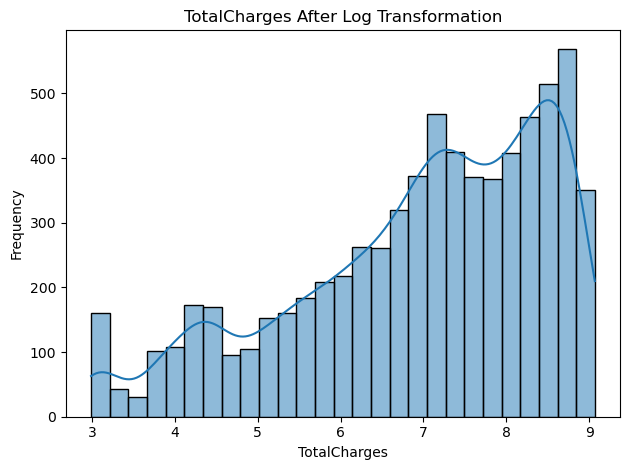

In [12]:
# Check distribution after transformation
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(
    data=df,
    x="TotalCharges",
    kde=True
)

plt.title("TotalCharges After Log Transformation")
plt.xlabel("TotalCharges")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Feature Selection

In [13]:
# Selecting Important Features

from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Features and target
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7043, 30)
y Shape: (7043,)


In [14]:
# Mutual Information Feature Selection

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

feature_scores = pd.Series(
    mi_scores,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_scores)

Feature Importance:
tenure                                   0.075548
Contract_Two year                        0.067045
InternetService_Fiber optic              0.053481
MonthlyCharges                           0.049626
OnlineSecurity_No internet service       0.044575
TotalCharges                             0.043447
PaymentMethod_Electronic check           0.043210
InternetService_No                       0.033875
StreamingTV_No internet service          0.033730
StreamingMovies_No internet service      0.032607
OnlineBackup_No internet service         0.030464
TechSupport_No internet service          0.029420
DeviceProtection_No internet service     0.025713
Dependents_Yes                           0.021981
PaperlessBilling_Yes                     0.020925
SeniorCitizen                            0.019711
Contract_One year                        0.019612
Partner_Yes                              0.014714
OnlineSecurity_Yes                       0.013121
StreamingMovies_Yes           

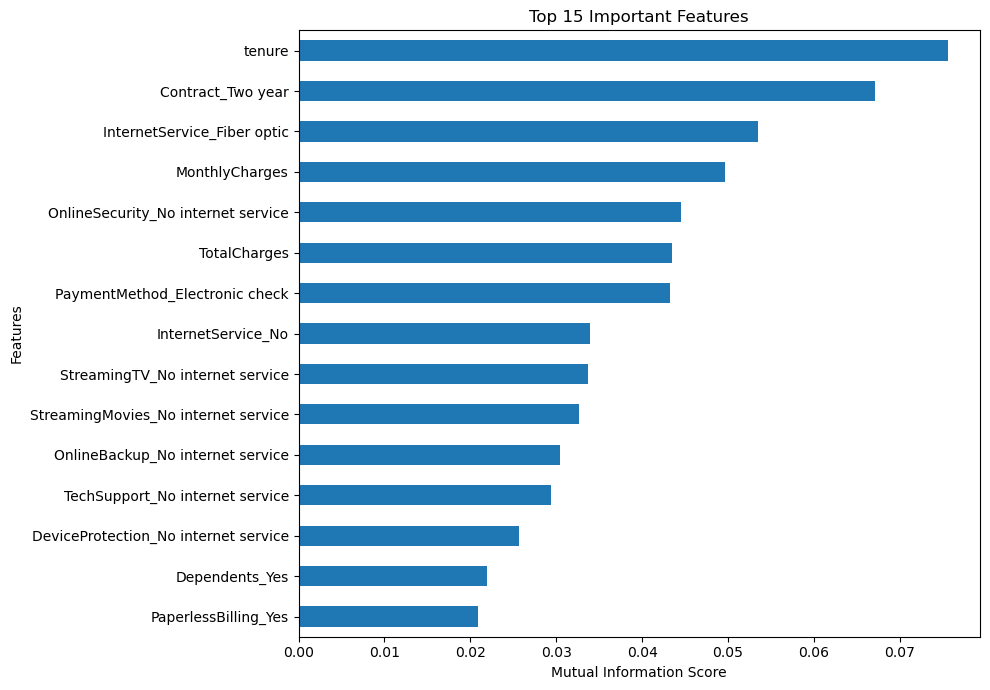

In [15]:
# Feature Importance Plot

feature_scores.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Top 15 Important Features")
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

# PCA

In [16]:
# Dimension Reduction → PCA

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features before PCA
scaler_pca = StandardScaler()

X_scaled = scaler_pca.fit_transform(X)

# PCA
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X.shape)
print("PCA Shape:", X_pca.shape)

Original Shape: (7043, 30)
PCA Shape: (7043, 30)


In [17]:
# Explained Variance

explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[3.31779640e-01 1.19879868e-01 9.02150088e-02 4.75152609e-02
 4.14550305e-02 4.11963008e-02 3.81231962e-02 3.33671843e-02
 3.12048681e-02 2.95243240e-02 2.66000847e-02 2.37815127e-02
 2.24859250e-02 2.05586914e-02 2.02246960e-02 1.75200257e-02
 1.55555587e-02 1.52430296e-02 1.46639753e-02 9.23016656e-03
 7.89394529e-03 1.95177360e-03 2.99333784e-05 4.46945553e-18
 2.39706777e-18 9.82564926e-19 4.66738107e-19 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


In [18]:
cumulative_variance = explained_variance.cumsum()

print(cumulative_variance)

[0.33177964 0.45165951 0.54187452 0.58938978 0.63084481 0.67204111
 0.71016431 0.74353149 0.77473636 0.80426068 0.83086077 0.85464228
 0.8771282  0.8976869  0.91791159 0.93543162 0.95098718 0.96623021
 0.98089418 0.99012435 0.99801829 0.99997007 1.         1.
 1.         1.         1.         1.         1.         1.        ]


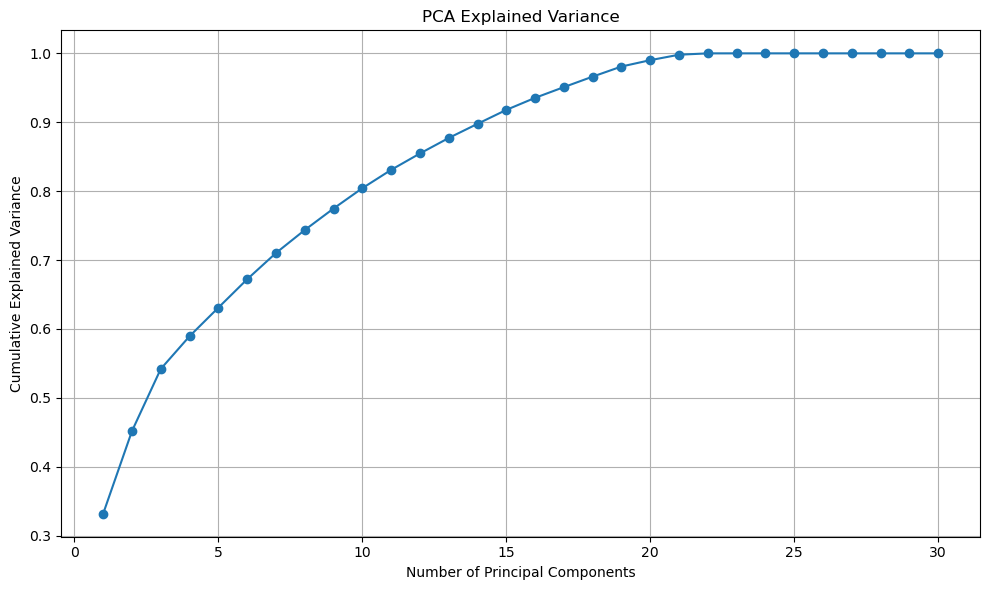

In [19]:
# PCA Explained Variance

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid()
plt.tight_layout()
plt.show()

# Develop the ML Model

In [20]:
# Features & Target

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7043, 30)
y Shape: (7043,)


In [21]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 30)
X_test : (1409, 30)
y_train: (5634,)
y_test : (1409,)


In [22]:
# Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (5634, 30)
X_test_scaled : (1409, 30)


In [23]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [24]:
# Model Evaluation

from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.8069552874378992


In [25]:
print(
    "Accuracy:",
    round(accuracy_lr * 100, 2),
    "%"
)

Accuracy: 80.7 %


In [26]:
# Logistic Regression Evaluation

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



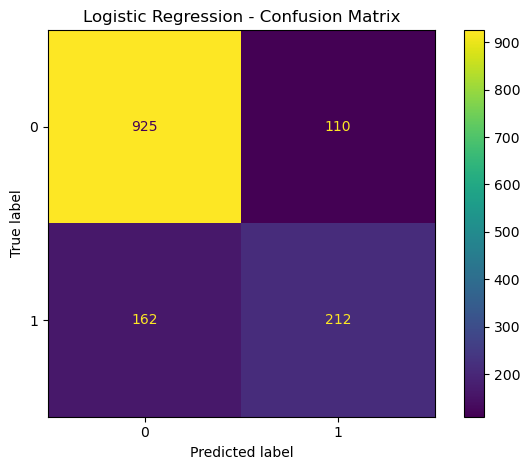

In [27]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

In [28]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(
    X_train_scaled,
    y_train
)

y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree Accuracy:")
print(round(accuracy_score(y_test, y_pred_dt) * 100, 2), "%")

Decision Tree Accuracy:
79.42 %


In [29]:
# Decision Tree Evaluation
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [30]:
# Train Multiple ML Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Models
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=8
    )
}

results = []

# Train & Evaluate
for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

# Results
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195
1,Decision Tree,0.794180,0.629630,0.545455,0.584527
2,Random Forest,0.806955,0.682143,0.510695,0.584098


# Hyperparameter Tuning

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)

Best Parameters: {'C': 10, 'solver': 'liblinear'}
Best CV F1 Score: 0.5989694084614318


In [32]:
# Best Logistic Regression Model

best_lr = grid.best_estimator_

y_pred_best = best_lr.predict(X_test_scaled)

print("Best Logistic Regression Evaluation:")
print(classification_report(y_test, y_pred_best))

Best Logistic Regression Evaluation:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



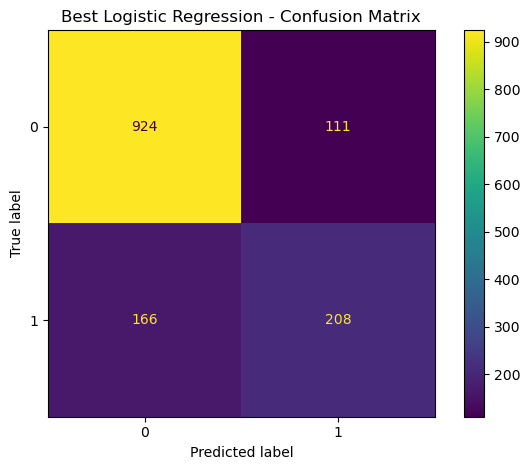

In [33]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Best Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC-AUC

In [34]:
# ROC-AUC

from sklearn.metrics import roc_auc_score, roc_curve

y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.8416


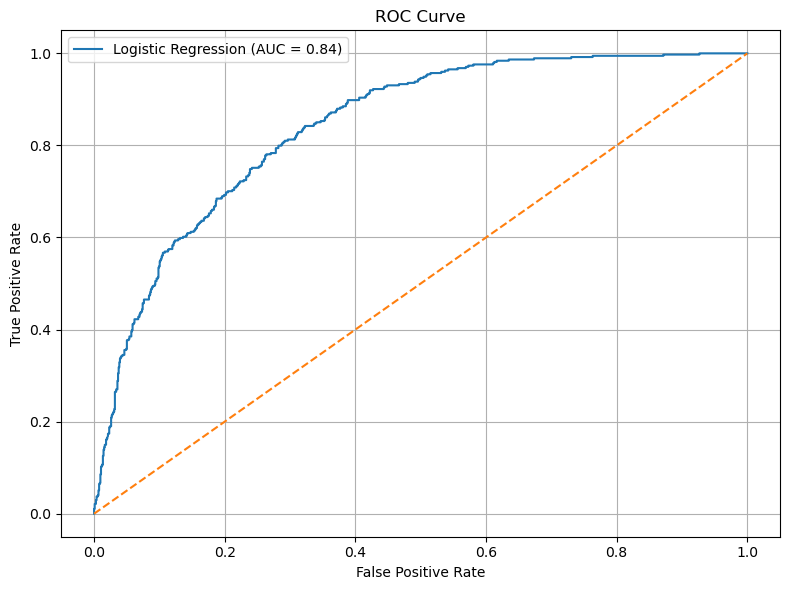

In [35]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Save Final Model

In [36]:
import joblib

# Save trained model
joblib.dump(
    lr_model,
    "churn_logistic_model.pkl"
)

# Save scaler
joblib.dump(
    scaler,
    "churn_scaler.pkl"
)

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


In [37]:
# Load Saved Model & Scaler

import joblib

model = joblib.load("churn_logistic_model.pkl")
scaler = joblib.load("churn_scaler.pkl")

print("Model loaded successfully!")
print("Scaler loaded successfully!")

Model loaded successfully!
Scaler loaded successfully!


In [38]:
# ============================================================
# Step 24.1 → Test Saved Model
# ============================================================

sample = X_test.iloc[[0]]

actual = y_test.iloc[0]

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)[0]
probability = model.predict_proba(sample_scaled)[0][1]

print("Actual Churn :", actual)
print("Predicted Churn:", prediction)
print("Churn Probability:", round(probability * 100, 2), "%")

Actual Churn : 0
Predicted Churn: 0
Churn Probability: 4.44 %


In [39]:
# Test Multiple Customers

import numpy as np

sample = X_test.sample(10, random_state=42)

actual = y_test.loc[sample.index]

sample_scaled = scaler.transform(sample)

predictions = model.predict(sample_scaled)
probabilities = model.predict_proba(sample_scaled)[:, 1]

results = pd.DataFrame({
    "Actual": actual.values,
    "Predicted": predictions,
    "Churn Probability (%)": np.round(probabilities * 100, 2)
})

results

,Actual,Predicted,Churn Probability (%)
0,0,0,24.61
1,0,0,41.68
2,0,0,0.31
3,1,1,66.36
4,0,0,2.40
5,0,0,0.50
6,0,0,7.19
7,1,0,28.75
8,0,0,22.15
9,1,1,73.06


In [40]:
import joblib

feature_columns = X_train.columns.tolist()

joblib.dump(
    feature_columns,
    "churn_features.pkl"
)

print("Feature columns saved successfully!")

Feature columns saved successfully!
